In [1]:
import pandas as pd
import ast
import os
from pathlib import Path
from dotenv import load_dotenv

# Load environment variables from .env file in project root
project_root = Path(__file__).parent.parent.parent if '__file__' in locals() else Path.cwd().parent.parent
dotenv_path = project_root / '.env'
load_dotenv(dotenv_path=dotenv_path) 

PAPER_PATH = Path(os.getenv('PAPER_PATH'))
print(PAPER_PATH)


RESULTS_US_PATH = '/share/pierson/matt/UAIR/outputs/2025-11-12/domain_agnostic_ai_us/full_event_pipeline_general_ai/outputs'
RESULTS_GLOBAL_PATH = '/share/pierson/matt/UAIR/outputs/2025-11-13/domain_agnostic_ai/full_event_pipeline_general_ai/outputs'


/share/pierson/matt/UAIR/papers/uair_brief


In [2]:
# IBM Plex Sans font setup via helper (no network)
import sys, os
sys.path.insert(0, '/share/pierson/matt/UAIR/notebooks')
from font_utils import load_ibm_plex_sans
import matplotlib.pyplot as plt

try:
    loaded_path = load_ibm_plex_sans()
    print(f'IBM Plex Sans font loaded from {loaded_path}')
except Exception as e:
    print(f'Could not load IBM Plex Sans, using sans-serif fallback: {e}')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']


IBM Plex Sans font loaded from /share/pierson/matt/UAIR/assets/fonts/ibm-plex-sans/fonts/complete/ttf/IBMPlexSans-Regular.ttf


In [5]:
# Load classify outputs for both US and global datasets
classify_global = pd.read_parquet(f"{RESULTS_GLOBAL_PATH}/classify/classify_all.parquet")
classify_us = pd.read_parquet(f"{RESULTS_US_PATH}/classify/classify_all.parquet")

print(f'Global classify: {len(classify_global)} articles')
print(f'US classify: {len(classify_us)} articles')

# Combine datasets
all_articles = pd.concat([classify_global, classify_us], ignore_index=True)
print(f'Combined dataset: {len(all_articles)} articles')

# Filter to relevant articles
relevant_articles = all_articles[all_articles['is_relevant'] == True].copy()
print(f'Relevant articles: {len(relevant_articles)} articles')

Global classify: 386449 articles
US classify: 29372 articles
Combined dataset: 415821 articles
Relevant articles: 8601 articles


In [6]:
relevant_articles.head()

,article_id,article_path,article_text,country,keyword_match_count,matched_keywords,relevant_keyword,year,relevance_answer,is_relevant,llm_output,classification_mode,latency_s,token_usage_prompt,token_usage_output,token_usage_total
5,2f0d178d78b1f8fb2f7f0d7296411b464be515f4,/share/ju/matt/sensing-ai-risks/data/global_su...,app uses adapted israeli airforce imaging tech...,ar,44,"[""algorithm"", ""app"", ""artificial intelligence""...",True,2016,YES,True,YES,llm_relevance,783.761432,NaN,NaN,NaN
32,357308677f52cd7367a6682bdcb83b2277c29985,/share/ju/matt/sensing-ai-risks/data/global_su...,delivering the goods: israel leads the way in ...,ar,59,"[""amazon"", ""app"", ""automatic"", ""autonomous"", ""...",True,2016,YES,True,YES,llm_relevance,783.265096,NaN,NaN,NaN
62,6c9aecd04c452e2eed350d3417f8ba15540517b8,/share/ju/matt/sensing-ai-risks/data/global_su...,israeli anti-tunnel tech could thwart us-mexic...,ar,29,"[""advanced"", ""algorithm"", ""analysis"", ""credit""...",True,2016,YES,True,YES,llm_relevance,782.544409,NaN,NaN,NaN
86,59e37d38f246d1dd6c0ad4ec3ab946a72932160c,/share/ju/matt/sensing-ai-risks/data/global_su...,moojis turns your selfies into personal emojis...,ar,25,"[""algorithm"", ""app"", ""creates"", ""data"", ""faceb...",True,2016,YES,True,YES,llm_relevance,782.142249,NaN,NaN,NaN
98,d414866d88462c835ce39227b185541bab7d15b5,/share/ju/matt/sensing-ai-risks/data/global_su...,israeli start-up presents: the optometrist in ...,ar,86,"[""advanced"", ""algorithm"", ""app"", ""data"", ""devi...",True,2016,YES,True,YES,llm_relevance,781.955043,NaN,NaN,NaN


In [7]:
# all_articles is already loaded in cell 1, so we can skip reloading it here
# This cell is kept for compatibility but all_articles is already available
print(f'Total articles: {len(all_articles)}')
print(f'Relevant articles: {len(relevant_articles)}')


Total articles: 415821
Relevant articles: 8601


In [8]:
all_articles.head()

,article_id,article_path,article_text,country,keyword_match_count,matched_keywords,relevant_keyword,year,relevance_answer,is_relevant,llm_output,classification_mode,latency_s,token_usage_prompt,token_usage_output,token_usage_total
0,9b7e70a743685c4aec2e3e91e3cdc337b7bcb4e1,/share/ju/matt/sensing-ai-risks/data/global_su...,el empresario que gana con la prohibiciã³n de ...,ar,12,"[""inversion"", ""product""]",True,2016,NO,False,NO,llm_relevance,783.829210,NaN,NaN,NaN
1,ca8caa1937ba81215af8ae6fc74b49be8cda7aa7,/share/ju/matt/sensing-ai-risks/data/global_su...,american express y sus 100 aã±os en la argenti...,ar,2,"[""app"", ""program""]",True,2016,NO,False,NO,llm_relevance,783.825265,NaN,NaN,NaN
2,474cf7cc1b1c10f6a0704716f79d4acc062f7e6c,/share/ju/matt/sensing-ai-risks/data/global_su...,11-year-old wounded in ramle stabbing; police ...,ar,17,"[""app"", ""attack"", ""bot"", ""city"", ""criminal"", ""...",True,2016,NO,False,NO,llm_relevance,783.806692,NaN,NaN,NaN
3,e0dfe324932bd891cc1abbead54aff5abcd78837,/share/ju/matt/sensing-ai-risks/data/global_su...,un esfuerzo bien distribuido\nen las redes\nde...,ar,1,"[""app""]",True,2016,NO,False,NO,llm_relevance,783.803724,NaN,NaN,NaN
4,41c4e3ac3dd573837298013af46574efc7b713d4,/share/ju/matt/sensing-ai-risks/data/global_su...,zaffaroni asegurã³ que cristina puede ir presa...,ar,6,"[""data"", ""digital"", ""intel"", ""program""]",True,2016,NO,False,NO,llm_relevance,783.788576,NaN,NaN,NaN


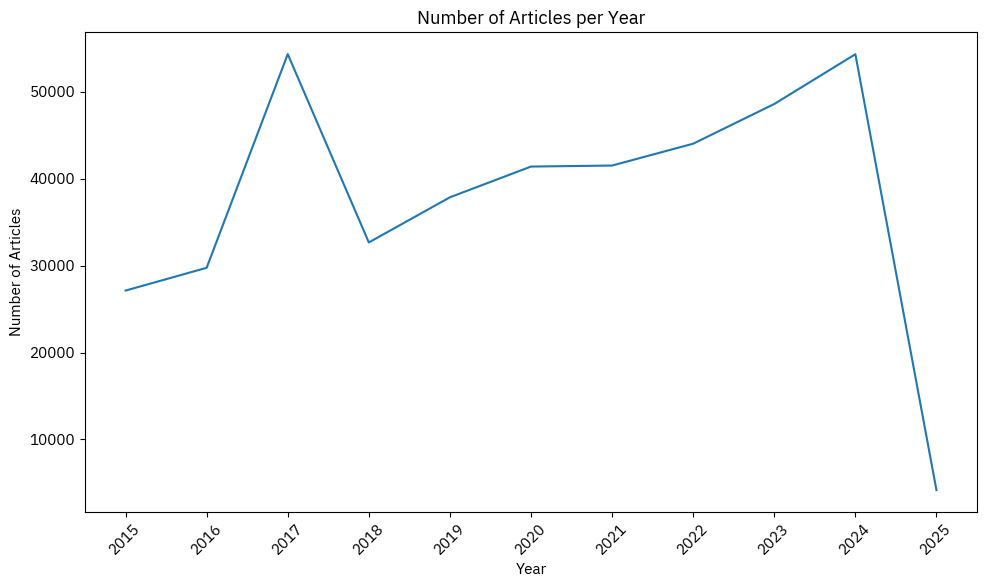

In [9]:
# make a line plot of the number of articles per year
import matplotlib.pyplot as plt

# Count articles per year - convert to int to avoid string issues
articles_per_year = all_articles['year'].astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
articles_per_year.plot(kind='line', ax=ax)
ax.set_title('Number of Articles per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')

# one x tick per year - use integer positions
ax.set_xticks(articles_per_year.index)
ax.set_xticklabels(articles_per_year.index, rotation=45)

plt.tight_layout()
plt.show()





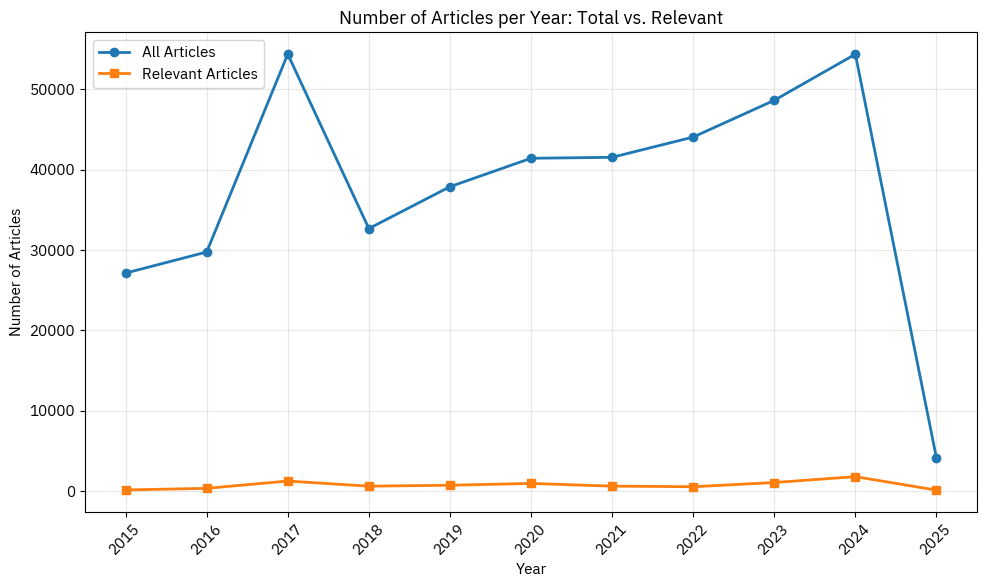

In [10]:
# Plot both total articles and relevant articles per year
fig, ax = plt.subplots(figsize=(10, 6))

# Count total articles per year
all_articles_per_year = all_articles['year'].astype(int).value_counts().sort_index()

# Count relevant articles per year
relevant_articles_per_year = all_articles[all_articles['is_relevant'] == True]['year'].astype(int).value_counts().sort_index()

# Plot both lines
ax.plot(all_articles_per_year.index, all_articles_per_year.values, marker='o', label='All Articles', linewidth=2)
ax.plot(relevant_articles_per_year.index, relevant_articles_per_year.values, marker='s', label='Relevant Articles', linewidth=2)

ax.set_title('Number of Articles per Year: Total vs. Relevant')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.legend()
ax.grid(True, alpha=0.3)

# Set x ticks to show every year
ax.set_xticks(all_articles_per_year.index)
ax.set_xticklabels(all_articles_per_year.index, rotation=45)

plt.tight_layout()
plt.show()


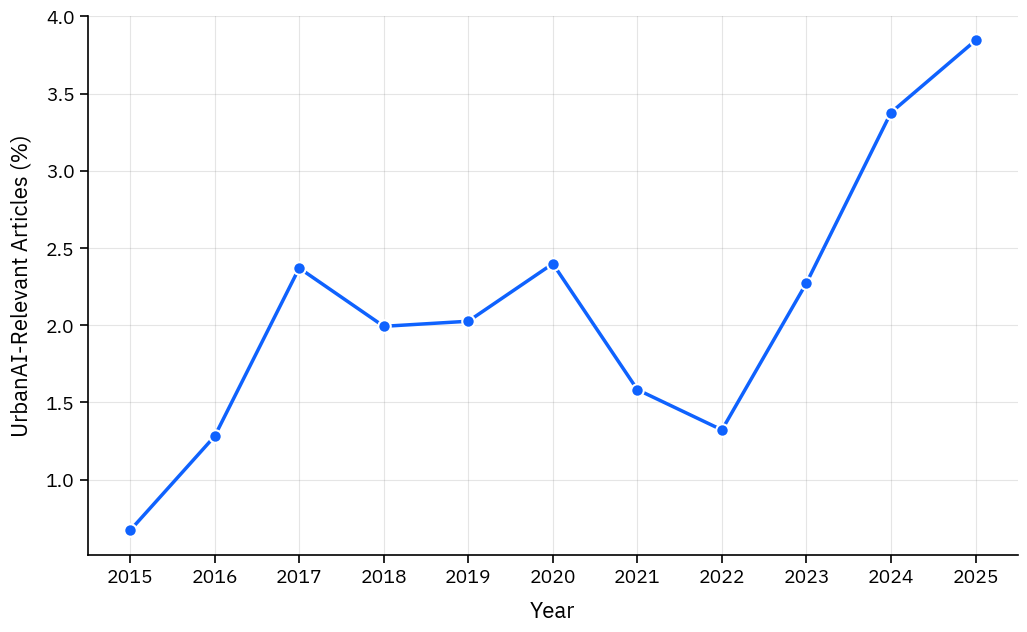

In [11]:


fig, ax = plt.subplots(figsize=(12, 7))

# Count total articles per year
all_articles_per_year = all_articles['year'].astype(int).value_counts().sort_index()

# Count relevant articles per year
relevant_articles_per_year = all_articles[all_articles['is_relevant'] == True]['year'].astype(int).value_counts().sort_index()

# Calculate fraction (reindex to ensure alignment)
fraction_relevant = relevant_articles_per_year.reindex(all_articles_per_year.index, fill_value=0) / all_articles_per_year

# Plot the fraction with enhanced styling
ax.plot(fraction_relevant.index, fraction_relevant.values * 100, 
        marker='o', linewidth=2.5, markersize=9,
        color='#0F62FE',  # IBM Blue
        markerfacecolor='#0F62FE',
        markeredgecolor='white',
        markeredgewidth=1.5,
        zorder=3)

# Styling

ax.set_xlabel('Year', fontsize=16, fontweight='500', labelpad=10)
ax.set_ylabel('UrbanAI-Relevant Articles (%)', fontsize=16, fontweight='500', labelpad=10)

# Grid styling
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.8, color='grey', zorder=0)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['bottom'].set_color('black')

# Set x ticks to show every year
ax.set_xticks(fraction_relevant.index)
ax.set_xticklabels(fraction_relevant.index, rotation=0, fontsize=14)

# Improve y-axis formatting
ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.2, colors='black')

# Set background color
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Save as PDF
plt.savefig(PAPER_PATH / "figures" /'fraction_relevant_articles_per_year.pdf', dpi=300, bbox_inches='tight')
# Save as PNG
plt.savefig(PAPER_PATH / "figures" /'fraction_relevant_articles_per_year.png', dpi=300, bbox_inches='tight')


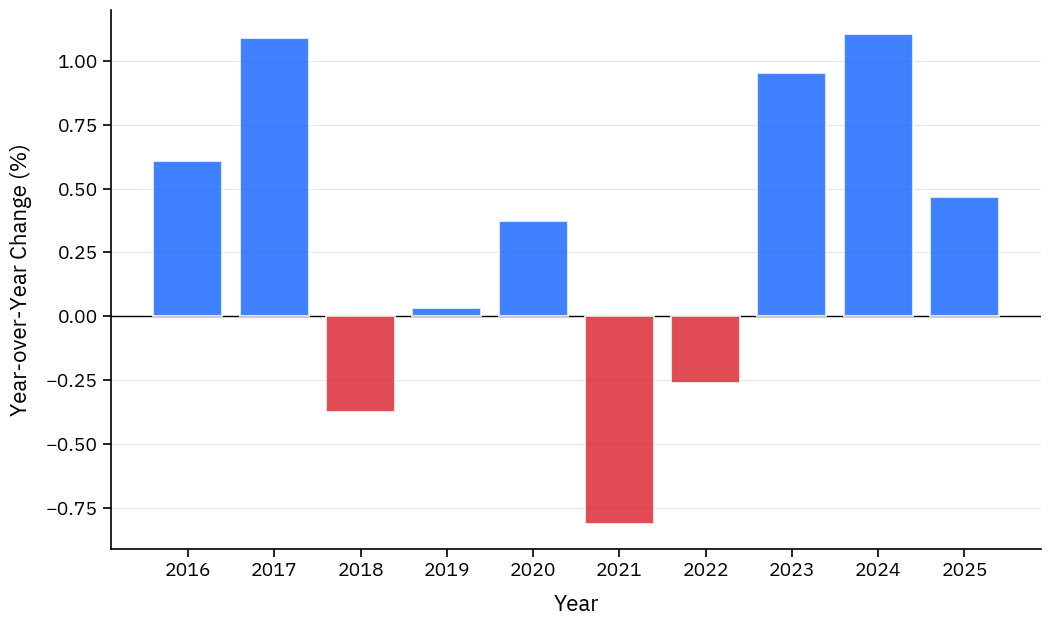

In [12]:
# Plot year-over-year increase in fraction of UrbanAI-Relevant Articles
fig, ax = plt.subplots(figsize=(12, 7))

# Count total articles per year
all_articles_per_year = all_articles['year'].astype(int).value_counts().sort_index()

# Count relevant articles per year
relevant_articles_per_year = all_articles[all_articles['is_relevant'] == True]['year'].astype(int).value_counts().sort_index()

# Calculate fraction (reindex to ensure alignment)
fraction_relevant = relevant_articles_per_year.reindex(all_articles_per_year.index, fill_value=0) / all_articles_per_year

# Calculate year-over-year change (absolute change in percentage points)
# Shift by 1 to get previous year's value, then calculate difference
fraction_relevant_pct = fraction_relevant * 100
yoy_change = fraction_relevant_pct.diff()

# Remove the first year (no previous year to compare to)
yoy_change = yoy_change.dropna()
years_with_change = yoy_change.index

# Plot the year-over-year change with enhanced styling
# Use different colors for positive vs negative changes
colors = ['#0F62FE' if val >= 0 else '#DA1E28' for val in yoy_change.values]  # IBM Blue for positive, IBM Red for negative

ax.bar(years_with_change, yoy_change.values, 
       color=colors, alpha=0.8, edgecolor='white', linewidth=1.5, zorder=3)

# Add a horizontal line at y=0 for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)

# Styling
ax.set_xlabel('Year', fontsize=16, fontweight='500', labelpad=10)
ax.set_ylabel('Year-over-Year Change (%)', fontsize=16, fontweight='500', labelpad=10)

# Grid styling
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.8, color='grey', zorder=0, axis='y')
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['bottom'].set_color('black')

# Set x ticks to show every year
ax.set_xticks(years_with_change)
ax.set_xticklabels(years_with_change, rotation=0, fontsize=14)

# Improve y-axis formatting
ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.2, colors='black')

# Set background color
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Save as PDF
plt.savefig(PAPER_PATH / "figures" /'yoy_change_fraction_relevant_articles.pdf', dpi=300, bbox_inches='tight')
# Save as PNG
plt.savefig(PAPER_PATH / "figures" /'yoy_change_fraction_relevant_articles.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
all_articles['country'].value_counts()

country
us    29372
ma    11617
th    10867
it    10583
cz    10563
gh    10518
fi    10241
co     9808
uy     9632
tw     9619
rs     9210
ca     9180
nl     9007
my     8986
es     8713
tt     8509
ar     8457
sg     8436
sv     8317
no     8308
ie     8252
au     8231
be     8060
cl     7783
il     7782
mt     7694
se     7589
lt     7576
gr     7570
lu     7488
ro     7390
pl     7315
hk     7313
vn     7290
tr     7038
lv     7018
pt     6915
nz     6626
at     6307
fr     6124
ee     6068
dk     5878
hu     5538
ir     5483
bg     5079
si     4614
et     4470
ve     3406
bd     3307
ch     3188
tz     3054
pe     2686
hr     2437
kr     2112
sa     1197
Name: count, dtype: int64